In [5]:
# ── FIX 3 VERIFICATION: Patient symptomatic/asymptomatic split ────
print("=" * 70)
print("FIX 3: PATIENT COUNT VERIFICATION")
print("=" * 70)

bashore = pd.read_csv(BASE / "macrophage_annotation/bashore_metadata.csv")

# Step 1: How many unique patients total?
# Deduplicate by age-sex-symptom (same logic you used for patient ID assignment)
patient_cols = [c for c in bashore.columns if c.lower() in 
    ["age", "sex", "symptomatic", "symptom", "symptomatic_status", 
     "condition", "disease_status"]]
print(f"\nCandidate patient-ID columns: {patient_cols}")
print(f"\nAll columns: {list(bashore.columns)}")

# Step 2: Show full symptomatic status breakdown
for col in bashore.columns:
    if any(kw in col.lower() for kw in ["sympt", "condition", "status", "disease"]):
        print(f"\n  {col} value counts:")
        print(bashore[col].value_counts().to_string())

# Step 3: If you have a patient_id column, use it directly
if "patient_id" in bashore.columns:
    pt = bashore.drop_duplicates("patient_id")
    symp_col = [c for c in pt.columns if "sympt" in c.lower()][0]
    print(f"\nUnique patients: {len(pt)}")
    print(f"Symptomatic split:\n{pt[symp_col].value_counts().to_string()}")
    print(f"\nPer-patient detail:")
    print(pt[["patient_id", "age", "sex", symp_col]].sort_values(symp_col).to_string())
else:
    # Fallback: show unique combos
    print("\nNo patient_id column — showing unique age/sex combos:")
    combo_cols = [c for c in bashore.columns if c.lower() in ["age", "sex"]] + \
                 [c for c in bashore.columns if "sympt" in c.lower()]
    if combo_cols:
        combos = bashore[combo_cols].drop_duplicates()
        print(combos.to_string())
        symp_col = [c for c in combo_cols if "sympt" in c.lower()][0]
        print(f"\nTotal unique patients: {len(combos)}")
        print(f"Split: {combos[symp_col].value_counts().to_dict()}")

FIX 3: PATIENT COUNT VERIFICATION

Candidate patient-ID columns: ['age', 'sex']

All columns: ['Run', 'age', 'Assay Type', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample', 'Bytes', 'Center Name', 'Collection_Date', 'Consent', 'DATASTORE filetype', 'DATASTORE provider', 'DATASTORE region', 'Experiment', 'geo_loc_name_country', 'geo_loc_name_country_continent', 'geo_loc_name', 'Instrument', 'Library Name', 'LibraryLayout', 'LibrarySelection', 'LibrarySource', 'Organism', 'Platform', 'ReleaseDate', 'create_date', 'version', 'Sample Name', 'sex', 'source_name', 'SRA Study', 'symptom_presence', 'tissue', 'RACE', 'library_type', 'adt']

  symptom_presence value counts:
symptom_presence
Symptomatic     37
Asymptomatic    15

No patient_id column — showing unique age/sex combos:
    age     sex symptom_presence
0    59    male      Symptomatic
1    58    male     Asymptomatic
2    75    male     Asymptomatic
3    66    male      Symptomatic
4    64    male     Asymptomatic
5    66  female    

In [19]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import mannwhitneyu, spearmanr, pearsonr
import matplotlib.pyplot as plt

BASE    = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
OUT_DIR = BASE / "clinical_analysis"

df_all  = pd.read_csv(OUT_DIR / "per_sample_ot_scores_ALL.csv")
bashore = pd.read_csv(BASE / "macrophage_annotation/bashore_metadata.csv")\
            .drop_duplicates("Run")\
            .rename(columns={"Run":"sample_id",
                             "symptom_presence":"symptom_status"})

df_all = df_all.merge(
    bashore[["sample_id","SRA Study"]],
    on="sample_id", how="left"
)

FIG5 = [
    "Lipid-Stressed / Foam Cells → Fibrotic / Hypoxic Macrophages",
    "Resident / Quiescent Macrophages → Fibrotic / Hypoxic Macrophages",
    "Scavenging / C1q+ Macrophages → Fibrotic / Hypoxic Macrophages",
    "Inflammatory Macrophages → Fibrotic / Hypoxic Macrophages",
]

df5 = df_all[df_all["transition"].isin(FIG5)].copy()

def sig(p):
    if p is None or np.isnan(p): return "—"
    return "***" if p<0.001 else "**" if p<0.01 \
           else "*" if p<0.05 else "ns"

# ── CHECK 1: RAW divergence (no normalization) ────────────────────
print("="*70)
print("CHECK 1: RAW divergence — no normalization")
print("Does fibrotic activity differ at all by symptom status?")
print("="*70)

for trans in FIG5:
    sub   = df5[df5["transition"]==trans]
    symp  = sub[sub["symptom_status"]=="Symptomatic"]["divergence"].values
    asymp = sub[sub["symptom_status"]=="Asymptomatic"]["divergence"].values
    if len(symp)<3 or len(asymp)<3:
        continue
    _, p  = mannwhitneyu(symp, asymp, alternative="two-sided")
    delta = np.mean(symp) - np.mean(asymp)
    print(f"\n  {trans}")
    print(f"  n={len(symp)}/{len(asymp)}  "
          f"mean_symp={np.mean(symp):.4f}  "
          f"mean_asymp={np.mean(asymp):.4f}  "
          f"Δ={delta:+.4f}  p={p:.4f}  {sig(p)}")

# ── CHECK 2: Are all fibrotic transitions correlated? ─────────────
print("\n\n"+"="*70)
print("CHECK 2: Are all fibrotic transitions correlated with each other?")
print("(if yes → normalization kills the signal)")
print("="*70)

wide = df5.pivot_table(
    index="sample_id", columns="transition",
    values="divergence"
).dropna(how="all")

short = {
    "Lipid-Stressed / Foam Cells → Fibrotic / Hypoxic Macrophages":       "Foam→Fibro",
    "Resident / Quiescent Macrophages → Fibrotic / Hypoxic Macrophages":  "Res→Fibro",
    "Scavenging / C1q+ Macrophages → Fibrotic / Hypoxic Macrophages":     "Scav→Fibro",
    "Inflammatory Macrophages → Fibrotic / Hypoxic Macrophages":          "Inflam→Fibro",
}
wide.columns = [short.get(c,c) for c in wide.columns]

cols = [c for c in ["Foam→Fibro","Res→Fibro","Scav→Fibro","Inflam→Fibro"]
        if c in wide.columns]

print(f"\n  Pairwise Spearman correlations (raw divergence):")
for i, c1 in enumerate(cols):
    for c2 in cols[i+1:]:
        both = wide[[c1,c2]].dropna()
        if len(both) < 5:
            continue
        rho, p = spearmanr(both[c1], both[c2])
        print(f"  {c1} vs {c2}")
        print(f"    rho={rho:+.3f}  p={p:.4f}  {sig(p)}  "
              f"{'→ highly correlated ⚠️' if abs(rho)>0.5 else '→ independent ✅'}")

# ── CHECK 3: COMPOSITE FIBROTIC SCORE ─────────────────────────────
print("\n\n"+"="*70)
print("CHECK 3: Composite fibrotic score")
print("Mean raw divergence across ALL fibrotic transitions per patient")
print("= overall fibrotic transition activity")
print("="*70)

composite = df5.groupby(["sample_id","symptom_status"])\
               ["divergence"].mean().reset_index()
composite.columns = ["sample_id","symptom_status","fibro_score"]

symp_c  = composite[composite["symptom_status"]=="Symptomatic"]["fibro_score"].values
asymp_c = composite[composite["symptom_status"]=="Asymptomatic"]["fibro_score"].values
_, p_c  = mannwhitneyu(symp_c, asymp_c, alternative="two-sided")
delta_c = np.mean(symp_c) - np.mean(asymp_c)

print(f"\n  Symptomatic:   n={len(symp_c)}  "
      f"mean={np.mean(symp_c):.4f}  median={np.median(symp_c):.4f}")
print(f"  Asymptomatic:  n={len(asymp_c)}  "
      f"mean={np.mean(asymp_c):.4f}  median={np.median(asymp_c):.4f}")
print(f"  Δ={delta_c:+.4f}  p={p_c:.4f}  {sig(p_c)}")
print(f"  {'✅ COMPOSITE SCORE IS SIGNIFICANT' if p_c<0.05 else '❌ not significant'}")

# SRP485269 only
comp_p1 = composite.merge(
    bashore[["sample_id","SRA Study"]], on="sample_id", how="left"
)
comp_p1 = comp_p1[comp_p1["SRA Study"]=="SRP485269"]
s1 = comp_p1[comp_p1["symptom_status"]=="Symptomatic"]["fibro_score"].values
a1 = comp_p1[comp_p1["symptom_status"]=="Asymptomatic"]["fibro_score"].values
if len(s1)>=3 and len(a1)>=3:
    _, p_srp = mannwhitneyu(s1, a1, alternative="two-sided")
    print(f"  SRP485269 only: n={len(s1)}/{len(a1)}  "
          f"p={p_srp:.4f}  {sig(p_srp)}")

# ── CHECK 4: INDIVIDUAL RAW WITH SRP CHECK ───────────────────────
print("\n\n"+"="*70)
print("CHECK 4: Raw divergence per transition + SRP485269 check")
print("(raw = no normalization, just the actual OT score)")
print("="*70)

for trans in FIG5:
    sub   = df5[df5["transition"]==trans]
    symp  = sub[sub["symptom_status"]=="Symptomatic"]["divergence"].values
    asymp = sub[sub["symptom_status"]=="Asymptomatic"]["divergence"].values
    if len(symp)<3 or len(asymp)<3:
        continue
    _, p  = mannwhitneyu(symp, asymp, alternative="two-sided")
    delta = np.mean(symp) - np.mean(asymp)

    sub_p1 = sub[sub["SRA Study"]=="SRP485269"]
    s1 = sub_p1[sub_p1["symptom_status"]=="Symptomatic"]["divergence"].values
    a1 = sub_p1[sub_p1["symptom_status"]=="Asymptomatic"]["divergence"].values
    _, p_srp = mannwhitneyu(s1, a1, alternative="two-sided") \
               if (len(s1)>=3 and len(a1)>=3) else (None, np.nan)

    direction = "Symp↑" if delta>0 else "Asymp↑"
    srp_ok    = np.isnan(p_srp) or p_srp < 0.05
    verdict   = "✅ CLEAN"     if (p<0.05 and srp_ok)     else \
                "⚠️ SIG/BATCH" if (p<0.05 and not srp_ok) else \
                "❌ ns"

    print(f"\n  {trans}")
    print(f"  n={len(symp)}/{len(asymp)}  Δ={delta:+.4f}  "
          f"p={p:.4f}  {sig(p)}  {direction}")
    print(f"  SRP485269: n={len(s1)}/{len(a1)}  "
          f"p={p_srp:.4f}  {sig(p_srp)}")
    print(f"  VERDICT: {verdict}")

print("\n\nDONE")

CHECK 1: RAW divergence — no normalization
Does fibrotic activity differ at all by symptom status?

  Lipid-Stressed / Foam Cells → Fibrotic / Hypoxic Macrophages
  n=8/7  mean_symp=0.3064  mean_asymp=0.2880  Δ=+0.0184  p=0.0401  *

  Resident / Quiescent Macrophages → Fibrotic / Hypoxic Macrophages
  n=17/11  mean_symp=0.3523  mean_asymp=0.3488  Δ=+0.0036  p=0.7067  ns

  Scavenging / C1q+ Macrophages → Fibrotic / Hypoxic Macrophages
  n=17/11  mean_symp=0.3417  mean_asymp=0.3208  Δ=+0.0209  p=0.1322  ns

  Inflammatory Macrophages → Fibrotic / Hypoxic Macrophages
  n=20/16  mean_symp=0.4973  mean_asymp=0.5167  Δ=-0.0194  p=0.2203  ns


CHECK 2: Are all fibrotic transitions correlated with each other?
(if yes → normalization kills the signal)

  Pairwise Spearman correlations (raw divergence):
  Foam→Fibro vs Res→Fibro
    rho=-0.057  p=0.8397  ns  → independent ✅
  Foam→Fibro vs Scav→Fibro
    rho=-0.568  p=0.0272  *  → highly correlated ⚠️
  Foam→Fibro vs Inflam→Fibro
    rho=-0.764

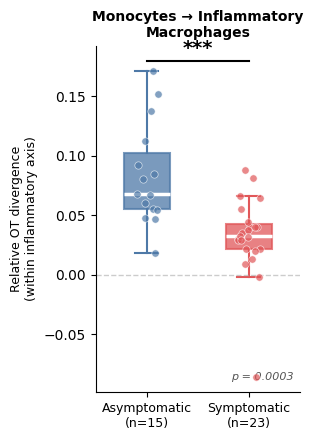

Saved: fig6_panelB_mono_inflam


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu
from pathlib import Path

BASE    = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
OUT_DIR = BASE / "figures/figure6"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SYMP_COLOR  = "#E15759"
ASYMP_COLOR = "#4E79A7"

df_all  = pd.read_csv(BASE / "clinical_analysis/per_sample_ot_scores_ALL.csv")
bashore = pd.read_csv(BASE / "macrophage_annotation/bashore_metadata.csv")\
            .drop_duplicates("Run")\
            .rename(columns={"Run":"sample_id",
                             "symptom_presence":"symptom_status"})
df_all  = df_all.merge(bashore[["sample_id"]], on="sample_id", how="left")

TRANS   = [
    "Monocytes → Inflammatory Macrophages",
    "Resident / Quiescent Macrophages → Inflammatory Macrophages",
    "Scavenging / C1q+ Macrophages → Inflammatory Macrophages",
]

df_ax   = df_all[df_all["transition"].isin(TRANS)].copy()
sm      = df_ax.groupby("sample_id")["divergence"].mean()
df_ax["rel_div"] = df_ax["divergence"] - df_ax["sample_id"].map(sm)

trans   = "Monocytes → Inflammatory Macrophages"
sub     = df_ax[df_ax["transition"]==trans]
symp    = sub[sub["symptom_status"]=="Symptomatic"]["rel_div"].values
asymp   = sub[sub["symptom_status"]=="Asymptomatic"]["rel_div"].values
_, p    = mannwhitneyu(symp, asymp, alternative="two-sided")

fig, ax = plt.subplots(figsize=(3.2, 4.5))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

rng = np.random.default_rng(42)

for i, (vals, color, label) in enumerate([
    (asymp, ASYMP_COLOR, "Asymptomatic"),
    (symp,  SYMP_COLOR,  "Symptomatic"),
]):
    bp = ax.boxplot(vals, positions=[i], widths=0.45,
                   patch_artist=True, notch=False,
                   medianprops=dict(color="white", lw=2.5),
                   whiskerprops=dict(color=color, lw=1.5),
                   capprops=dict(color=color, lw=1.5),
                   flierprops=dict(marker="", lw=0),
                   boxprops=dict(facecolor=color, alpha=0.75,
                                edgecolor=color, lw=1.5))
    jitter = rng.uniform(-0.12, 0.12, len(vals))
    ax.scatter(i + jitter, vals, color=color, alpha=0.7,
              s=28, zorder=5, edgecolors="white", linewidths=0.5)

# Significance bar
y_max = max(symp.max(), asymp.max())
y_bar = y_max + 0.008
ax.plot([0, 1], [y_bar, y_bar], color="black", lw=1.5)
ax.text(0.5, y_bar + 0.003, "***", ha="center", va="bottom",
       fontsize=14, fontweight="bold", color="black")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Asymptomatic\n(n=15)", "Symptomatic\n(n=23)"],
                  fontsize=9)
ax.set_ylabel("Relative OT divergence\n(within inflammatory axis)",
             fontsize=9)
ax.set_title("Monocytes → Inflammatory\nMacrophages",
            fontsize=10, fontweight="bold")
ax.axhline(0, color="#aaaaaa", lw=1, linestyle="--", alpha=0.6)

for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

ax.text(0.97, 0.03, f"p = {p:.4f}",
       transform=ax.transAxes, ha="right", va="bottom",
       fontsize=8, color="#555555", style="italic")

plt.tight_layout()
plt.savefig(OUT_DIR / "fig6_panelB_mono_inflam.pdf",
           bbox_inches="tight", dpi=300)
plt.savefig(OUT_DIR / "fig6_panelB_mono_inflam.png",
           bbox_inches="tight", dpi=300)
plt.show()
print("Saved: fig6_panelB_mono_inflam")

In [9]:
from pathlib import Path
import glob
import os

BASE = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")

# ── CHECK SLURM LOGS ──────────────────────────────────────────────
print("="*65)
print("SLURM LOG FILES")
print("="*65)
logs = sorted(glob.glob("panel_d_*.log"))
if not logs:
    logs = sorted(glob.glob("/storage/homefs/sv24v923/*.log"))
if not logs:
    logs = sorted(glob.glob(str(Path.home() / "*.log")))

for log in logs[-3:]:
    print(f"\n{log}")
    print("─"*50)
    with open(log) as f:
        content = f.read()
    # Print last 80 lines — where crash happened
    lines = content.strip().split("\n")
    for line in lines[-80:]:
        print(line)

SLURM LOG FILES

/storage/homefs/sv24v923/hs_err_pid4124163.log
──────────────────────────────────────────────────
apicid		: 123
initial apicid	: 123
fpu		: yes
fpu_exception	: yes
cpuid level	: 16
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ht syscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid extd_apicid aperfmperf rapl pni pclmulqdq monitor ssse3 fma cx16 sse4_1 sse4_2 movbe popcnt aes xsave avx f16c rdrand lahf_lm cmp_legacy svm extapic cr8_legacy abm sse4a misalignsse 3dnowprefetch osvw ibs skinit wdt tce topoext perfctr_core perfctr_nb bpext perfctr_llc mwaitx cpb cat_l3 cdp_l3 hw_pstate ssbd mba ibrs ibpb stibp vmmcall fsgsbase bmi1 avx2 smep bmi2 cqm rdt_a rdseed adx smap clflushopt clwb sha_ni xsaveopt xsavec xgetbv1 xsaves cqm_llc cqm_occup_llc cqm_mbm_total cqm_mbm_local clzero irperf xsaveerptr rdpru wbnoinvd amd_ppin arat npt lbrv svm_lock nrip_save tsc

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, spearmanr
from pathlib import Path

BASE = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")

# Load per-sample scores
df_all = pd.read_csv(BASE / "clinical_analysis/per_sample_ot_scores_ALL.csv")
print("df_all columns:", df_all.columns.tolist())
print("df_all shape:", df_all.shape)
print("df_all transitions:", df_all['transition'].unique())

# Load patient metadata
bashore = pd.read_csv(BASE / "macrophage_annotation/bashore_metadata.csv")
print("\nbashore columns:", bashore.columns.tolist())

# Check actual column name for symptom status
for col in bashore.columns:
    if 'symptom' in col.lower():
        print(f"  Found symptom column: '{col}' -> {bashore[col].unique()}")

# Rename carefully
bashore = bashore.drop_duplicates("Run")
bashore = bashore.rename(columns={"Run": "sample_id"})

# Find the symptom column name dynamically
symptom_col = [c for c in bashore.columns if 'symptom' in c.lower()][0]
print(f"\nUsing symptom column: '{symptom_col}'")

# Create patient_id
bashore['patient_id'] = bashore['age'].astype(str) + '_' + bashore['sex'].astype(str)
print(f"Patients: {bashore['patient_id'].nunique()}")
print(bashore.groupby('patient_id')['sample_id'].count().sort_values(ascending=False))

# Drop symptom_status from df_all if it already exists (from prior merge)
if 'symptom_status' in df_all.columns:
    df_all = df_all.drop(columns=['symptom_status'])

# Merge — only bring in what we need
df_merged = df_all.merge(
    bashore[['sample_id', symptom_col, 'patient_id']],
    on='sample_id', how='inner'
)
df_merged = df_merged.rename(columns={symptom_col: 'symptom_status'})

print(f"\nMerged shape: {df_merged.shape}")
print(f"Merged columns: {df_merged.columns.tolist()}")
print(f"Symptom counts:\n{df_merged.groupby('symptom_status')['patient_id'].nunique()}")

# Aggregate to patient level
df_patient = df_merged.groupby(
    ['patient_id', 'symptom_status', 'transition']
)['divergence'].mean().reset_index()

print(f"\nPatient-level shape: {df_patient.shape}")
print(f"Transitions: {df_patient['transition'].unique()}")

# Compute relative divergence at patient level
# First check exact transition names in your data
print("\nAll transition names:")
for t in sorted(df_patient['transition'].unique()):
    print(f"  '{t}'")

# Match transition names to what's actually in the data
all_trans = df_patient['transition'].unique()
mono_inflam = [t for t in all_trans if 'Mono' in t and 'Inflam' in t]
scav_inflam = [t for t in all_trans if 'Scav' in t and 'Inflam' in t or 
               'C1q' in t and 'Inflam' in t]
res_inflam = [t for t in all_trans if 'Res' in t and 'Inflam' in t or
              'Quiescent' in t and 'Inflam' in t]

print(f"\nMatched transitions:")
print(f"  Mono→Inflam: {mono_inflam}")
print(f"  Scav→Inflam: {scav_inflam}")
print(f"  Res→Inflam:  {res_inflam}")

INFLAM_TRANS = mono_inflam + scav_inflam + res_inflam
print(f"  Total: {len(INFLAM_TRANS)} transitions")

df_inflam = df_patient[df_patient['transition'].isin(INFLAM_TRANS)].copy()
patient_means = df_inflam.groupby('patient_id')['divergence'].mean()
df_inflam['rel_div'] = df_inflam['divergence'] - \
    df_inflam['patient_id'].map(patient_means)

# ── Test each transition ──
print("\n" + "="*60)
print("PATIENT-LEVEL CLINICAL ANALYSIS")
print("="*60)

for trans_list, label in [
    (mono_inflam, "Mono→Inflam"),
    (scav_inflam, "Scav→Inflam"),
]:
    if not trans_list:
        print(f"\n  {label}: NO MATCHING TRANSITION FOUND")
        continue
    trans = trans_list[0]
    sub = df_inflam[df_inflam['transition'] == trans]
    symp = sub[sub['symptom_status'].str.contains('ymptom', case=False) & 
               ~sub['symptom_status'].str.contains('Asymptom', case=False)]['rel_div'].values
    asymp = sub[sub['symptom_status'].str.contains('Asymptom', case=False)]['rel_div'].values
    
    if len(symp) > 0 and len(asymp) > 0:
        _, p_val = mannwhitneyu(symp, asymp, alternative='two-sided')
        print(f"\n  {label} (patient-level):")
        print(f"    Symptomatic:   n={len(symp)}, median={np.median(symp):.4f}")
        print(f"    Asymptomatic:  n={len(asymp)}, median={np.median(asymp):.4f}")
        print(f"    Mann-Whitney p = {p_val:.4f}")
    else:
        print(f"\n  {label}: empty groups (symp={len(symp)}, asymp={len(asymp)})")

# ── Spearman at patient level ──
if mono_inflam and scav_inflam:
    wide = df_inflam.pivot_table(
        index=['patient_id', 'symptom_status'],
        columns='transition', values='rel_div'
    ).reset_index()
    
    x_col = mono_inflam[0]
    y_col = scav_inflam[0]
    
    wide_clean = wide.dropna(subset=[x_col, y_col])
    rho, p_corr = spearmanr(wide_clean[x_col], wide_clean[y_col])
    print(f"\n  Anti-correlation (patient-level):")
    print(f"    Spearman rho = {rho:.2f}, p = {p_corr:.4f}")
    print(f"    n = {len(wide_clean)} patients")

# ── Also do fibrotic axis ──
foam_fibro = [t for t in all_trans if 'Foam' in t and 'Fibro' in t or
              'Lipid' in t and 'Fibro' in t]
inflam_fibro = [t for t in all_trans if 'Inflam' in t and 'Fibro' in t]

if foam_fibro and inflam_fibro:
    wide_fibro = df_patient.pivot_table(
        index=['patient_id', 'symptom_status'],
        columns='transition', values='divergence'  # raw, not relative
    ).reset_index()
    
    x_col_f = foam_fibro[0]
    y_col_f = inflam_fibro[0]
    
    wide_fibro_clean = wide_fibro.dropna(subset=[x_col_f, y_col_f])
    rho_f, p_f = spearmanr(wide_fibro_clean[x_col_f], wide_fibro_clean[y_col_f])
    print(f"\n  Fibrotic anti-correlation (patient-level):")
    print(f"    Spearman rho = {rho_f:.2f}, p = {p_f:.4f}")
    print(f"    n = {len(wide_fibro_clean)} patients")

df_all columns: ['sample_id', 'symptom_status', 'batch', 'source', 'target', 'transition', 'divergence', 'n_src', 'n_tgt', 'sample_mean_div', 'relative_div', 'plasticity']
df_all shape: (612, 12)
df_all transitions: ['Scavenging / C1q+ Macrophages → Inflammatory Macrophages'
 'Resident / Quiescent Macrophages → Inflammatory Macrophages'
 'Monocytes → Inflammatory Macrophages'
 'Monocytes → Resident / Quiescent Macrophages'
 'Lipid-Stressed / Foam Cells → Fibrotic / Hypoxic Macrophages'
 'Scavenging / C1q+ Macrophages → Fibrotic / Hypoxic Macrophages'
 'Resident / Quiescent Macrophages → Fibrotic / Hypoxic Macrophages'
 'Monocytes → Scavenging / C1q+ Macrophages'
 'Monocytes → Fibrotic / Hypoxic Macrophages'
 'Monocytes → Lipid-Stressed / Foam Cells'
 'Resident / Quiescent Macrophages → Scavenging / C1q+ Macrophages'
 'Differentiating / Transitional → Monocytes'
 'Differentiating / Transitional → Resident / Quiescent Macrophages'
 'Fibrotic / Hypoxic Macrophages → Resident / Quiescent M

In [7]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, spearmanr
from pathlib import Path

BASE     = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
META_F   = BASE / "macrophage_annotation/bashore_metadata.csv"
OT_F     = BASE / "clinical_analysis/per_sample_ot_scores_ALL.csv"
OUT_F    = BASE / "clinical_analysis/patient_level_results.csv"

# ── 1. Load metadata ───────────────────────────────────────────────
meta = pd.read_csv(META_F)
print(f"Metadata: {len(meta)} rows")
print(f"Columns: {meta.columns.tolist()}")

# ── 2. Patient ID mapping ──────────────────────────────────────────
# mRNA BioSamples for multimodal patients (exclude ADT BioSamples)
MRNA_BIOSAMPLES = {
    "SAMN39550052": ("P_81M_S",  81, "male",   "Symptomatic"),
    "SAMN39550054": ("P_80M_S",  80, "male",   "Symptomatic"),
    "SAMN39550056": ("P_78F_S",  78, "female", "Symptomatic"),
    "SAMN39550058": ("P_75M_S",  75, "male",   "Symptomatic"),
    "SAMN39550060": ("P_71M_A",  71, "male",   "Asymptomatic"),
    "SAMN39550062": ("P_79M_S",  79, "male",   "Symptomatic"),
}
ADT_BIOSAMPLES = {
    "SAMN39550051", "SAMN39550053", "SAMN39550055",
    "SAMN39550057", "SAMN39550059", "SAMN39550061",
}

# RNA-only patients — BioSample is unambiguous
RNA_BIOSAMPLES = {
    "SAMN39546307": ("P_59M_S",  59, "male",   "Symptomatic"),
    "SAMN39546308": ("P_58M_A",  58, "male",   "Asymptomatic"),
    "SAMN39546309": ("P_75M_A",  75, "male",   "Asymptomatic"),
    "SAMN39546310": ("P_66M_S",  66, "male",   "Symptomatic"),
    "SAMN39546311": ("P_64M_A",  64, "male",   "Asymptomatic"),
    "SAMN39546312": ("P_62M_A",  62, "male",   "Asymptomatic"),
    "SAMN39546313": ("P_76F_A",  76, "female", "Asymptomatic"),
    "SAMN39546314": ("P_46M_S",  46, "male",   "Symptomatic"),
    "SAMN39546315": ("P_66F_S",  66, "female", "Symptomatic"),
    "SAMN39546316": ("P_64M_S",  64, "male",   "Symptomatic"),
    "SAMN39546317": ("P_67M_A",  67, "male",   "Asymptomatic"),
    "SAMN39546318": ("P_89M_S",  89, "male",   "Symptomatic"),
}

ALL_BIOSAMPLES = {**{k: v for k, v in MRNA_BIOSAMPLES.items()},
                  **{k: v for k, v in RNA_BIOSAMPLES.items()}}

# Build Run → patient_id mapping
# First check what BioSample column is called
print(f"\nMetadata columns: {meta.columns.tolist()}")

# Find BioSample column
biosample_col = [c for c in meta.columns
                 if "biosample" in c.lower() or "BioSample" in c]
print(f"BioSample column candidates: {biosample_col}")

biosample_col = biosample_col[0] if biosample_col else "BioSample"

# Filter out ADT runs
meta_rna = meta[~meta[biosample_col].isin(ADT_BIOSAMPLES)].copy()
print(f"\nAfter removing ADT runs: {len(meta_rna)} rows "
      f"(removed {len(meta) - len(meta_rna)})")

# Map BioSample → patient_id
meta_rna["patient_id"]      = meta_rna[biosample_col].map(
    lambda x: ALL_BIOSAMPLES.get(x, (None,))[0])
meta_rna["symptom_status"]  = meta_rna[biosample_col].map(
    lambda x: ALL_BIOSAMPLES.get(x, (None, None, None, None))[3])

# Check unmapped
unmapped = meta_rna[meta_rna["patient_id"].isna()]
if len(unmapped) > 0:
    print(f"\n⚠ Unmapped BioSamples ({len(unmapped)} runs):")
    print(unmapped[[biosample_col, "Run"]].to_string())

meta_rna = meta_rna.dropna(subset=["patient_id"])
run_to_patient = meta_rna.set_index("Run")["patient_id"].to_dict()
run_to_symptom = meta_rna.set_index("Run")["symptom_status"].to_dict()

print(f"\nRun→patient mappings: {len(run_to_patient)}")
print(f"Unique patients: {meta_rna['patient_id'].nunique()}")

# ── 3. Load OT scores ──────────────────────────────────────────────
ot = pd.read_csv(OT_F)
print(f"\nOT scores: {len(ot)} rows")
print(f"Transitions: {ot['transition'].unique().tolist()}")
print(f"Samples in OT: {ot['sample_id'].nunique()}")

# ── 4. Merge with patient mapping ─────────────────────────────────
ot["patient_id"]     = ot["sample_id"].map(run_to_patient)
ot["symptom_status"] = ot["sample_id"].map(run_to_symptom)

ot_mapped = ot.dropna(subset=["patient_id"])
print(f"\nOT rows after patient mapping: {len(ot_mapped)} "
      f"(dropped {len(ot) - len(ot_mapped)} unmapped)")
print(f"Unique patients with OT data: {ot_mapped['patient_id'].nunique()}")

# ── 5. Aggregate to patient level ─────────────────────────────────
patient_div = (
    ot_mapped
    .groupby(["patient_id", "symptom_status", "transition"])
    .agg(
        mean_divergence=("divergence", "mean"),
        n_runs=("sample_id", "nunique"),
    )
    .reset_index()
)

# ── 6. Relative divergence for inflammatory axis ───────────────────
INFLAM_TRANSITIONS = [
    "Monocytes → Inflammatory Macrophages",
    "Resident / Quiescent Macrophages → Inflammatory Macrophages",
    "Scavenging / C1q+ Macrophages → Inflammatory Macrophages",
]

inflam_df = patient_div[
    patient_div["transition"].isin(INFLAM_TRANSITIONS)
].copy()

# Per-patient mean across the 3 inflammatory transitions
patient_inflam_mean = (
    inflam_df
    .groupby("patient_id")["mean_divergence"]
    .mean()
    .rename("inflam_axis_mean")
)

inflam_df = inflam_df.merge(patient_inflam_mean, on="patient_id")
inflam_df["relative_divergence"] = (
    inflam_df["mean_divergence"] - inflam_df["inflam_axis_mean"]
)

# ── 7a. Verification table ─────────────────────────────────────────
print("\n" + "="*70)
print("PATIENT-LEVEL VERIFICATION TABLE")
print("="*70)
pivot = inflam_df.pivot_table(
    index=["patient_id", "symptom_status"],
    columns="transition",
    values=["mean_divergence", "relative_divergence"],
).round(4)
print(pivot.to_string())

# ── 8. Statistical tests ───────────────────────────────────────────
def get_relative(transition):
    sub = inflam_df[inflam_df["transition"] == transition]
    symp  = sub[sub["symptom_status"] == "Symptomatic"]["relative_divergence"].values
    asymp = sub[sub["symptom_status"] == "Asymptomatic"]["relative_divergence"].values
    return symp, asymp

def get_raw(transition):
    sub = patient_div[patient_div["transition"] == transition]
    return sub.set_index("patient_id")["mean_divergence"]

print("\n" + "="*70)
print("STATISTICAL RESULTS")
print("="*70)

# 7a. Mann-Whitney: Mono→Inflam
T_MONO  = "Monocytes → Inflammatory Macrophages"
T_SCAV  = "Scavenging / C1q+ Macrophages → Inflammatory Macrophages"

symp_mono,  asymp_mono  = get_relative(T_MONO)
symp_scav,  asymp_scav  = get_relative(T_SCAV)

stat, p = mannwhitneyu(symp_mono, asymp_mono, alternative="two-sided")
print(f"\nMann-Whitney — Mono→Inflam (relative div):")
print(f"  Symptomatic   (n={len(symp_mono)}): {symp_mono.round(4)}")
print(f"  Asymptomatic  (n={len(asymp_mono)}): {asymp_mono.round(4)}")
print(f"  U={stat:.1f}  p={p:.4f}")

stat, p = mannwhitneyu(symp_scav, asymp_scav, alternative="two-sided")
print(f"\nMann-Whitney — Scav→Inflam (relative div):")
print(f"  Symptomatic   (n={len(symp_scav)}): {symp_scav.round(4)}")
print(f"  Asymptomatic  (n={len(asymp_scav)}): {asymp_scav.round(4)}")
print(f"  U={stat:.1f}  p={p:.4f}")

# 7c. Spearman: Mono→Inflam vs Scav→Inflam
mono_rel = inflam_df[inflam_df["transition"] == T_MONO].set_index("patient_id")["relative_divergence"]
scav_rel = inflam_df[inflam_df["transition"] == T_SCAV].set_index("patient_id")["relative_divergence"]
common   = mono_rel.index.intersection(scav_rel.index)
rho, p   = spearmanr(mono_rel[common], scav_rel[common])
print(f"\nSpearman — Mono→Inflam vs Scav→Inflam (relative div):")
print(f"  n={len(common)}  ρ={rho:.3f}  p={p:.4f}")

# 7d. Spearman: Foam→Fibro vs Inflam→Fibro
T_FOAM_F  = "Lipid-Stressed / Foam Cells → Fibrotic / Hypoxic Macrophages"
T_INFL_F  = "Inflammatory Macrophages → Fibrotic / Hypoxic Macrophages"
foam_raw  = get_raw(T_FOAM_F)
infl_raw  = get_raw(T_INFL_F)
common2   = foam_raw.index.intersection(infl_raw.index)
rho2, p2  = spearmanr(foam_raw[common2], infl_raw[common2])
print(f"\nSpearman — Foam→Fibro vs Inflam→Fibro (raw div):")
print(f"  n={len(common2)}  ρ={rho2:.3f}  p={p2:.4f}")

# ── 9. Save ───────────────────────────────────────────────────────
OUT_F.parent.mkdir(parents=True, exist_ok=True)
patient_div.to_csv(OUT_F, index=False)
print(f"\nSaved: {OUT_F}")

Metadata: 52 rows
Columns: ['Run', 'age', 'Assay Type', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample', 'Bytes', 'Center Name', 'Collection_Date', 'Consent', 'DATASTORE filetype', 'DATASTORE provider', 'DATASTORE region', 'Experiment', 'geo_loc_name_country', 'geo_loc_name_country_continent', 'geo_loc_name', 'Instrument', 'Library Name', 'LibraryLayout', 'LibrarySelection', 'LibrarySource', 'Organism', 'Platform', 'ReleaseDate', 'create_date', 'version', 'Sample Name', 'sex', 'source_name', 'SRA Study', 'symptom_presence', 'tissue', 'RACE', 'library_type', 'adt']

Metadata columns: ['Run', 'age', 'Assay Type', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample', 'Bytes', 'Center Name', 'Collection_Date', 'Consent', 'DATASTORE filetype', 'DATASTORE provider', 'DATASTORE region', 'Experiment', 'geo_loc_name_country', 'geo_loc_name_country_continent', 'geo_loc_name', 'Instrument', 'Library Name', 'LibraryLayout', 'LibrarySelection', 'LibrarySource', 'Organism', 'Platform', 'ReleaseDate', '

In [8]:
import pandas as pd
from pathlib import Path

BASE = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
OT_F = BASE / "clinical_analysis/per_sample_ot_scores_ALL.csv"
META_F = BASE / "macrophage_annotation/bashore_metadata.csv"

ot   = pd.read_csv(OT_F)
meta = pd.read_csv(META_F)

# Runs belonging to P_58M_A (SAMN39546308) and P_89M_S (SAMN39546318)
target_biosamples = {"SAMN39546308", "SAMN39546318"}
target_runs = meta[meta["BioSample"].isin(target_biosamples)]["Run"].tolist()
print(f"Runs for these two patients: {target_runs}")

# Check what transitions exist for these runs
subset = ot[ot["sample_id"].isin(target_runs)]
print(f"\nRows in OT scores for these runs: {len(subset)}")
print(f"\nTransitions present:")
print(subset[["sample_id", "transition", "n_src", "n_tgt"]].to_string())

# Check specifically for Mono→Inflam
mono_inflam = ot[ot["transition"] == "Monocytes → Inflammatory Macrophages"]
print(f"\nAll samples with Mono→Inflam: {mono_inflam['sample_id'].nunique()}")
print(f"Missing runs: {set(target_runs) - set(mono_inflam['sample_id'].tolist())}")

Runs for these two patients: ['SRR27684931', 'SRR27684951', 'SRR27684952']

Rows in OT scores for these runs: 14

Transitions present:
       sample_id                                                         transition  n_src  n_tgt
64   SRR27684951           Scavenging / C1q+ Macrophages → Inflammatory Macrophages     42     93
65   SRR27684951        Resident / Quiescent Macrophages → Inflammatory Macrophages     54     93
129  SRR27684931           Scavenging / C1q+ Macrophages → Inflammatory Macrophages    160     23
130  SRR27684931        Resident / Quiescent Macrophages → Inflammatory Macrophages    137     23
201  SRR27684952           Scavenging / C1q+ Macrophages → Inflammatory Macrophages     43     95
202  SRR27684952        Resident / Quiescent Macrophages → Inflammatory Macrophages     58     95
287  SRR27684951                          Monocytes → Scavenging / C1q+ Macrophages     11     42
288  SRR27684952                          Monocytes → Scavenging / C1q+ Macrophag

# Final figures

Spearman ρ=-0.797  p=0.0002  n=16


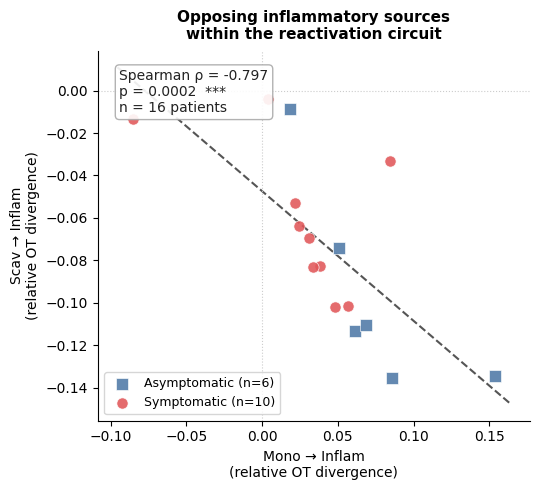

Saved fig6B_scatter_mono_vs_scav


In [14]:
#!/usr/bin/env python3
"""
Fig6B — Scatter: Mono→Inflam vs Scav→Inflam relative divergence
Main figure panel — Spearman ρ=-0.797, p=0.0002
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from pathlib import Path

BASE    = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
OUT_DIR = BASE / "figures/figure6"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(BASE / "clinical_analysis/patient_level_results.csv")

INFLAM_TRANSITIONS = [
    "Monocytes → Inflammatory Macrophages",
    "Resident / Quiescent Macrophages → Inflammatory Macrophages",
    "Scavenging / C1q+ Macrophages → Inflammatory Macrophages",
]

inflam = df[df["transition"].isin(INFLAM_TRANSITIONS)].copy()
patient_mean = (
    inflam.groupby("patient_id")["mean_divergence"]
    .mean().rename("axis_mean")
)
inflam = inflam.merge(patient_mean, on="patient_id")
inflam["relative_div"] = inflam["mean_divergence"] - inflam["axis_mean"]

T_MONO = "Monocytes → Inflammatory Macrophages"
T_SCAV = "Scavenging / C1q+ Macrophages → Inflammatory Macrophages"

mono = inflam[inflam["transition"] == T_MONO].set_index("patient_id")[
    ["relative_div", "symptom_status"]].dropna()
scav = inflam[inflam["transition"] == T_SCAV].set_index("patient_id")[
    ["relative_div"]].dropna()

common = mono.index.intersection(scav.index)
x      = mono.loc[common, "relative_div"].values
y      = scav.loc[common, "relative_div"].values
status = mono.loc[common, "symptom_status"].values

rho, p = spearmanr(x, y)
print(f"Spearman ρ={rho:.3f}  p={p:.4f}  n={len(common)}")

COL_ASYMP = "#4E79A7"
COL_SYMP  = "#E15759"

fig, ax = plt.subplots(figsize=(5.5, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for s, color, marker in [("Asymptomatic", COL_ASYMP, "s"),
                          ("Symptomatic",  COL_SYMP,  "o")]:
    mask = status == s
    n    = mask.sum()
    ax.scatter(x[mask], y[mask], c=color, marker=marker,
               s=65, alpha=0.88, zorder=3,
               linewidths=0.5, edgecolors="white",
               label=f"{s} (n={n})")

# Regression line
m, b = np.polyfit(x, y, 1)
xl   = np.linspace(x.min() - 0.01, x.max() + 0.01, 100)
ax.plot(xl, m * xl + b, color="#555555",
        lw=1.5, linestyle="--", zorder=2)

ax.axhline(0, color="#cccccc", lw=0.8, linestyle=":")
ax.axvline(0, color="#cccccc", lw=0.8, linestyle=":")

stars = "***" if p < 0.001 else ("**" if p < 0.01 else
        ("*" if p < 0.05 else "ns"))
ax.text(0.05, 0.95,
        f"Spearman ρ = {rho:.3f}\np = {p:.4f}  {stars}\nn = {len(common)} patients",
        transform=ax.transAxes, va="top", ha="left",
        fontsize=10, color="#222222",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor="#aaaaaa", alpha=0.9))

ax.set_xlabel("Mono → Inflam\n(relative OT divergence)",  fontsize=10)
ax.set_ylabel("Scav → Inflam\n(relative OT divergence)", fontsize=10)
ax.set_title("Opposing inflammatory sources\nwithin the reactivation circuit",
             fontsize=11, fontweight="bold", pad=8)
ax.legend(framealpha=0.8, fontsize=9, loc="lower left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
for ext in ["pdf", "png"]:
    fig.savefig(OUT_DIR / f"fig6B_scatter_mono_vs_scav.{ext}",
                dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved fig6B_scatter_mono_vs_scav")

In [6]:
from pathlib import Path
import pandas as pd

GRAD_DIR = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline/ot_gradients_v3")

print(f"{'CSV file':<35s} {'rows':>8s}")
print("-" * 45)
for f in sorted(GRAD_DIR.glob("*.csv")):
    if f.name.startswith("decoupler"):
        continue
    df = pd.read_csv(f, nrows=1)
    n = sum(1 for _ in open(f)) - 1
    print(f"{f.name:<35s} {n:>8,}")

CSV file                                rows
---------------------------------------------
Fibro_to_Scav.csv                      5,484
Foam_to_Fibro.csv                      8,962
Inflam_to_Fibro.csv                   14,907
Mono_to_Fibro.csv                     20,449
Mono_to_Foam.csv                      20,449
Mono_to_Inflam.csv                    20,449
Mono_to_Res.csv                       20,449
Mono_to_Scav.csv                      20,449
Res_to_Fibro.csv                      10,685
Res_to_Inflam.csv                     10,685
Scav_to_Fibro.csv                     21,146
Scav_to_Inflam.csv                    21,146


In [ ]:
import decoupler as dc
import pandas as pd
import numpy as np
import scanpy as sc
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from pathlib import Path

BASE = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
GRAD_DIR = BASE / "ot_gradients_v3"

print("Loading atlas...")
adata = sc.read_h5ad(
    BASE / "macrophage_annotation/Macrophage_Atlas_FINAL_v3_CLEAN_ANNOTATED.h5ad"
)
print(f"Atlas: {adata.n_obs} cells x {adata.n_vars} genes")

print("Loading CollecTRI...")
net = dc.get_collectri(organism='human', split_complexes=False)
print(f"Network: {net.shape[0]} interactions, {net['source'].nunique()} TFs")

CT_MAP = {
    'Scav':   'Scavenging / C1q+ Macrophages',
    'Mono':   'Monocytes',
    'Foam':   'Lipid-Stressed / Foam Cells',
    'Res':    'Resident / Quiescent Macrophages',
    'Inflam': 'Inflammatory Macrophages',
    'Fibro':  'Fibrotic / Hypoxic Macrophages',
}

transitions = [
    'Scav_to_Inflam',
    'Res_to_Inflam',
    'Mono_to_Inflam',
    'Mono_to_Foam',
    'Mono_to_Res',
    'Mono_to_Scav',
    'Mono_to_Fibro',
    'Foam_to_Fibro',
    'Res_to_Fibro',
    'Inflam_to_Fibro',
    'Fibro_to_Scav',
    'Scav_to_Fibro',
]

all_results = {}

for transition in transitions:
    print(f"\n{'='*60}")
    print(f"  {transition}")
    print(f"{'='*60}")
    
    csv_path = GRAD_DIR / f"{transition}.csv"
    if not csv_path.exists():
        print(f"  CSV not found, skipping.")
        continue
    
    grad = pd.read_csv(csv_path)
    src_key = transition.split('_to_')[0]
    src_ct = CT_MAP[src_key]
    
    src_mask = adata.obs['cell_type_meta_v3'] == src_ct
    src_adata = adata[src_mask].copy()
    
    print(f"  Atlas source cells: {src_adata.n_obs}")
    print(f"  Gradient CSV rows:  {len(grad)}")
    
    if src_adata.n_obs != len(grad):
        print(f"  WARNING: mismatch! Skipping.")
        continue
    
    # Check which quartile column exists
    if 'ot_quartile_corrected' in grad.columns:
        q_col = 'ot_quartile_corrected'
    elif 'ot_quartile' in grad.columns:
        q_col = 'ot_quartile'
    else:
        print(f"  WARNING: no quartile column found! Columns: {grad.columns.tolist()}")
        continue
    
    src_adata.obs['ot_quartile'] = grad[q_col].values
    q1q4 = src_adata[src_adata.obs['ot_quartile'].isin(['Q1', 'Q4'])].copy()
    n_q1 = (q1q4.obs['ot_quartile'] == 'Q1').sum()
    n_q4 = (q1q4.obs['ot_quartile'] == 'Q4').sum()
    print(f"  Q1: {n_q1} cells, Q4: {n_q4} cells")
    
    print(f"  Running ULM...")
    dc.run_ulm(
        mat=q1q4,
        net=net,
        source='source',
        target='target',
        weight='weight',
        verbose=False,
        use_raw=False,
    )
    
    tf_act = q1q4.obsm['ulm_estimate']
    if hasattr(tf_act, 'values'):
        X_tf = tf_act.values
        tf_names = tf_act.columns.tolist()
    else:
        X_tf = np.array(tf_act)
        tf_names = [f"TF_{i}" for i in range(X_tf.shape[1])]
    
    quartiles = q1q4.obs['ot_quartile'].values
    q1_mask = quartiles == 'Q1'
    q4_mask = quartiles == 'Q4'
    
    results_list = []
    for i, tf in enumerate(tf_names):
        vals_q1 = X_tf[q1_mask, i]
        vals_q4 = X_tf[q4_mask, i]
        stat, pval = mannwhitneyu(vals_q4, vals_q1, alternative='two-sided')
        mean_q1 = np.mean(vals_q1)
        mean_q4 = np.mean(vals_q4)
        diff = mean_q4 - mean_q1
        results_list.append({
            'names': tf,
            'scores': diff,
            'mean_Q1': mean_q1,
            'mean_Q4': mean_q4,
            'pvals': pval,
            'transition': transition,
        })
    
    result = pd.DataFrame(results_list)
    reject, pvals_adj, _, _ = multipletests(result['pvals'].values, method='fdr_bh')
    result['pvals_adj'] = pvals_adj
    result = result.sort_values('scores', ascending=False)
    all_results[transition] = result
    
    print(f"\n  Top 10 TFs INCREASED in Q4:")
    for _, row in result.head(10).iterrows():
        sig = '***' if row['pvals_adj'] < 0.001 else '**' if row['pvals_adj'] < 0.01 else '*' if row['pvals_adj'] < 0.05 else 'ns'
        print(f"    {row['names']:15s}  diff={row['scores']:+.4f}  "
              f"Q1={row['mean_Q1']:+.3f}  Q4={row['mean_Q4']:+.3f}  "
              f"padj={row['pvals_adj']:.2e}  {sig}")
    
    print(f"\n  Top 10 TFs DECREASED in Q4:")
    for _, row in result.tail(10).iloc[::-1].iterrows():
        sig = '***' if row['pvals_adj'] < 0.001 else '**' if row['pvals_adj'] < 0.01 else '*' if row['pvals_adj'] < 0.05 else 'ns'
        print(f"    {row['names']:15s}  diff={row['scores']:+.4f}  "
              f"Q1={row['mean_Q1']:+.3f}  Q4={row['mean_Q4']:+.3f}  "
              f"padj={row['pvals_adj']:.2e}  {sig}")
    
    result.to_csv(GRAD_DIR / f"decoupler_TF_{transition}.csv", index=False)

combined = pd.concat(all_results.values(), ignore_index=True)
combined.to_csv(GRAD_DIR / "decoupler_TF_all_transitions.csv", index=False)

print(f"\n\n{'='*70}")
print("COMPARISON: Top 10 UP TFs per transition")
print(f"{'='*70}")
for t in transitions:
    if t in all_results:
        top = all_results[t].head(10)['names'].tolist()
        print(f"  {t:20s}: {', '.join(top)}")

print(f"\n{'='*70}")
print("COMPARISON: Top 10 DOWN TFs per transition")
print(f"{'='*70}")
for t in transitions:
    if t in all_results:
        bot = all_results[t].tail(10)['names'].tolist()[::-1]
        print(f"  {t:20s}: {', '.join(bot)}")

print("\nDone.")

Loading atlas...
Atlas: 81633 cells x 23496 genes
Loading CollecTRI...
Network: 43159 interactions, 1186 TFs

  Scav_to_Inflam
  Atlas source cells: 21146
  Gradient CSV rows:  21146
  Q1: 5287 cells, Q4: 5287 cells
  Running ULM...

  Top 10 TFs INCREASED in Q4:
    RFXAP            diff=+2.6006  Q1=+15.073  Q4=+17.673  padj=1.37e-234  ***
    RFXANK           diff=+2.4422  Q1=+14.018  Q4=+16.460  padj=1.29e-232  ***
    CIITA            diff=+2.1931  Q1=+10.665  Q4=+12.858  padj=4.71e-298  ***
    RFX5             diff=+2.1643  Q1=+12.239  Q4=+14.403  padj=7.58e-236  ***
    RELA             diff=+1.8515  Q1=+7.489  Q4=+9.341  padj=0.00e+00  ***
    NFKB1            diff=+1.7682  Q1=+6.851  Q4=+8.619  padj=8.92e-269  ***
    CREB1            diff=+1.7218  Q1=+7.080  Q4=+8.802  padj=0.00e+00  ***
    FOXO3            diff=+1.6796  Q1=+3.954  Q4=+5.633  padj=0.00e+00  ***
    REL              diff=+1.6577  Q1=+6.996  Q4=+8.654  padj=3.90e-252  ***
    NFKB             diff=+1.6515  Q1=

: 

In [2]:
import pandas as pd
from scipy.stats import spearmanr
from pathlib import Path

BASE = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
df = pd.read_csv(BASE / "clinical_analysis/patient_level_results.csv")

print("Columns:", df.columns.tolist())
print(f"Shape: {df.shape}")

T_MONO = "Monocytes → Inflammatory Macrophages"
T_SCAV = "Scavenging / C1q+ Macrophages → Inflammatory Macrophages"
T_RES  = "Resident / Quiescent Macrophages → Inflammatory Macrophages"

# Get RAW divergence (not relative)
mono = df[df["transition"] == T_MONO].set_index("patient_id")[["mean_divergence", "symptom_status"]]
scav = df[df["transition"] == T_SCAV].set_index("patient_id")[["mean_divergence"]]
res  = df[df["transition"] == T_RES].set_index("patient_id")[["mean_divergence"]]

common = mono.index.intersection(scav.index)

# RAW divergence correlation
rho_raw, p_raw = spearmanr(
    mono.loc[common, "mean_divergence"].values,
    scav.loc[common, "mean_divergence"].values
)
print(f"\nRAW divergence (Mono vs Scav):")
print(f"  rho={rho_raw:.3f}, p={p_raw:.4f}, n={len(common)}")

# RELATIVE divergence correlation (your current method)
merged = mono.loc[common].copy()
merged["scav"] = scav.loc[common, "mean_divergence"].values
merged["res"] = res.loc[common, "mean_divergence"].values
merged["mean_3"] = (merged["mean_divergence"] + merged["scav"] + merged["res"]) / 3
merged["rel_mono"] = merged["mean_divergence"] - merged["mean_3"]
merged["rel_scav"] = merged["scav"] - merged["mean_3"]

rho_rel, p_rel = spearmanr(merged["rel_mono"].values, merged["rel_scav"].values)
print(f"\nRELATIVE divergence (Mono vs Scav):")
print(f"  rho={rho_rel:.3f}, p={p_rel:.4f}, n={len(common)}")

print(f"\nComparison:")
print(f"  Raw:      rho={rho_raw:.3f}  p={p_raw:.4f}")
print(f"  Relative: rho={rho_rel:.3f}  p={p_rel:.4f}")

if abs(rho_raw) > 0.4 and p_raw < 0.05:
    print("\n  --> Anti-correlation holds on raw values. REAL BIOLOGY.")
elif abs(rho_raw) < 0.2:
    print("\n  --> Anti-correlation vanishes on raw values. NORMALIZATION ARTIFACT.")
else:
    print("\n  --> Weaker on raw but still present. PARTIALLY REAL.")

Columns: ['patient_id', 'symptom_status', 'transition', 'mean_divergence', 'n_runs']
Shape: (260, 5)

RAW divergence (Mono vs Scav):
  rho=0.044, p=0.8711, n=16

RELATIVE divergence (Mono vs Scav):
  rho=-0.797, p=0.0002, n=16

Comparison:
  Raw:      rho=0.044  p=0.8711
  Relative: rho=-0.797  p=0.0002

  --> Anti-correlation vanishes on raw values. NORMALIZATION ARTIFACT.


In [1]:
import pandas as pd, numpy as np
from scipy.stats import mannwhitneyu
from pathlib import Path

CLIN = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline/clinical_analysis")
print([p.name for p in CLIN.glob("*.csv")])

df = pd.read_csv(CLIN / "per_sample_ot_scores_full.csv")   # swap name if needed
print(df.shape, list(df.columns))
df.head(10)

['per_axis_diagnostics.csv', 'stats_symptomatic_vs_asymptomatic.csv', 'patient_plasticity_scores.csv', 'per_sample_ot_scores_combined.csv', 'per_sample_ot_scores_ALL.csv', 'per_sample_ot_stats_combined.csv', 'transition_diagnostics_full.csv', 'per_sample_ot_scores_full.csv', 'per_sample_ot_stats.csv', 'stats_severe_vs_moderate.csv', 'FINAL_transition_diagnostics.csv', 'final_check_no_age.csv', 'per_sample_ot_scores.csv', 'per_sample_ot_scores_new_transitions.csv', 'patient_level_results.csv', 'per_transition_relative_stats.csv']
(248, 9) ['sample_id', 'symptom_status', 'batch', 'source', 'target', 'transition', 'divergence', 'n_src', 'n_tgt']


,sample_id,symptom_status,batch,source,target,transition,divergence,n_src,n_tgt
0,SRR27684940,Asymptomatic,bashore,Scavenging / C1q+ Macrophages,Inflammatory Macrophages,Scavenging / C1q+ Macrophages → Inflammatory M...,0.610323,887,278
1,SRR27684940,Asymptomatic,bashore,Resident / Quiescent Macrophages,Inflammatory Macrophages,Resident / Quiescent Macrophages → Inflammator...,0.778026,66,278
2,SRR27684940,Asymptomatic,bashore,Monocytes,Inflammatory Macrophages,Monocytes → Inflammatory Macrophages,0.839502,72,278
3,SRR27684940,Asymptomatic,bashore,Monocytes,Resident / Quiescent Macrophages,Monocytes → Resident / Quiescent Macrophages,0.775969,72,66
4,SRR27684940,Asymptomatic,bashore,Lipid-Stressed / Foam Cells,Fibrotic / Hypoxic Macrophages,Lipid-Stressed / Foam Cells → Fibrotic / Hypox...,0.675908,21,183
5,SRR27684940,Asymptomatic,bashore,Scavenging / C1q+ Macrophages,Fibrotic / Hypoxic Macrophages,Scavenging / C1q+ Macrophages → Fibrotic / Hyp...,0.722041,887,183
6,SRR27684940,Asymptomatic,bashore,Resident / Quiescent Macrophages,Fibrotic / Hypoxic Macrophages,Resident / Quiescent Macrophages → Fibrotic / ...,0.658708,66,183
7,SRR27684938,Symptomatic,bashore,Monocytes,Resident / Quiescent Macrophages,Monocytes → Resident / Quiescent Macrophages,0.807062,24,155
8,SRR27685161,Symptomatic,bashore,Scavenging / C1q+ Macrophages,Inflammatory Macrophages,Scavenging / C1q+ Macrophages → Inflammatory M...,0.621868,315,243
9,SRR27685161,Symptomatic,bashore,Resident / Quiescent Macrophages,Inflammatory Macrophages,Resident / Quiescent Macrophages → Inflammator...,0.753710,124,243


In [3]:
import pandas as pd
from scipy.stats import mannwhitneyu
from pathlib import Path
CLIN = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline/clinical_analysis")

df = pd.read_csv(CLIN / "per_sample_ot_scores_full.csv")
print(sorted(df.transition.unique()))
print(df.symptom_status.value_counts())

INFLAM = [t for t in df.transition.unique() if t.endswith(("Inflam", "Inflammatory"))]
inf = df[df.transition.isin(INFLAM)].copy()
inf["relative"] = inf.divergence - inf.groupby("sample_id").divergence.transform("mean")

for t in INFLAM:
    s = inf[inf.transition == t]
    a = s[s.symptom_status.str.lower().str.startswith("sym")]["relative"]
    b = s[s.symptom_status.str.lower().str.startswith("asym")]["relative"]
    if len(a) < 2 or len(b) < 2:
        print(t, "too small", sorted(s.symptom_status.unique())); continue
    p = mannwhitneyu(a, b, alternative="two-sided")[1]
    print(f"{t}: sym n={len(a)} mean={a.mean():+.4f} | asym n={len(b)} mean={b.mean():+.4f} | p={p:.4f}"
          f"  -> HIGHER in {'ASYM' if b.mean() > a.mean() else 'SYM'}")

['Lipid-Stressed / Foam Cells → Fibrotic / Hypoxic Macrophages', 'Monocytes → Inflammatory Macrophages', 'Monocytes → Resident / Quiescent Macrophages', 'Resident / Quiescent Macrophages → Fibrotic / Hypoxic Macrophages', 'Resident / Quiescent Macrophages → Inflammatory Macrophages', 'Scavenging / C1q+ Macrophages → Fibrotic / Hypoxic Macrophages', 'Scavenging / C1q+ Macrophages → Inflammatory Macrophages']
symptom_status
Symptomatic     153
Asymptomatic     95
Name: count, dtype: int64


In [4]:
import pandas as pd
from scipy.stats import mannwhitneyu
from pathlib import Path
CLIN = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline/clinical_analysis")

df = pd.read_csv(CLIN / "per_sample_ot_scores_full.csv")

INFLAM = [t for t in df.transition.unique() if "Inflammatory" in t.split("→")[1]]
print("inflammatory axis:", INFLAM)

inf = df[df.transition.isin(INFLAM)].copy()
inf["relative"] = inf.divergence - inf.groupby("sample_id").divergence.transform("mean")

for t in INFLAM:
    s = inf[inf.transition == t]
    a = s[s.symptom_status == "Symptomatic"]["relative"]
    b = s[s.symptom_status == "Asymptomatic"]["relative"]
    p = mannwhitneyu(a, b, alternative="two-sided")[1]
    print(f"\n{t}")
    print(f"  sym  n={len(a):3d} mean={a.mean():+.4f} median={a.median():+.4f}")
    print(f"  asym n={len(b):3d} mean={b.mean():+.4f} median={b.median():+.4f}")
    print(f"  p={p:.4f}  ->  HIGHER in {'ASYMPTOMATIC' if b.mean() > a.mean() else 'SYMPTOMATIC'}")

inflammatory axis: ['Scavenging / C1q+ Macrophages → Inflammatory Macrophages', 'Resident / Quiescent Macrophages → Inflammatory Macrophages', 'Monocytes → Inflammatory Macrophages']

Scavenging / C1q+ Macrophages → Inflammatory Macrophages
  sym  n= 26 mean=-0.0824 median=-0.0857
  asym n= 16 mean=-0.1100 median=-0.1179
  p=0.0116  ->  HIGHER in SYMPTOMATIC

Resident / Quiescent Macrophages → Inflammatory Macrophages
  sym  n= 26 mean=+0.0200 median=+0.0166
  asym n= 16 mean=+0.0050 median=+0.0261
  p=0.9897  ->  HIGHER in SYMPTOMATIC

Monocytes → Inflammatory Macrophages
  sym  n= 25 mean=+0.0649 median=+0.0694
  asym n= 15 mean=+0.1121 median=+0.1064
  p=0.0000  ->  HIGHER in ASYMPTOMATIC


In [5]:
import pandas as pd
from pathlib import Path
CLIN = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline/clinical_analysis")
for f in ["stats_symptomatic_vs_asymptomatic.csv", "patient_level_results.csv"]:
    d = pd.read_csv(CLIN / f)
    print("="*70); print(f, d.shape); print(d.to_string())

stats_symptomatic_vs_asymptomatic.csv (7, 7)
                            cluster    mean_a    mean_b    log2fc      pval  pval_adj  significant
0                         Monocytes  0.088052  0.144856  0.718186  0.016416  0.114914        False
1  Resident / Quiescent Macrophages  0.132494  0.239176  0.852141  0.122287  0.856008        False
2    Differentiating / Transitional  0.014593  0.017754  0.282806  0.128481  0.899366        False
3     Scavenging / C1q+ Macrophages  0.344961  0.289922 -0.250770  0.285587  1.000000        False
4          Inflammatory Macrophages  0.293181  0.231448 -0.341101  0.333370  1.000000        False
5    Fibrotic / Hypoxic Macrophages  0.110460  0.062477 -0.822113  0.489523  1.000000        False
6       Lipid-Stressed / Foam Cells  0.016259  0.014368 -0.178419  0.772454  1.000000        False
patient_level_results.csv (260, 5)
    patient_id symptom_status                                                         transition  mean_divergence  n_runs
0     